# 02 — Exploratory Data Analysis
**DSA210 Term Project · Nehir Eylül Balcı**

Explores distributions, top countries, pairwise relationships, gender gap, and continental patterns.

In [7]:
from google.colab import files
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

uploaded = files.upload()
df = pd.read_csv("volleyball_economic_dataset.csv")
print(f"{len(df)} countries loaded")

Saving volleyball_economic_dataset.csv to volleyball_economic_dataset (1).csv
38 countries loaded


## 2.1 Distributions

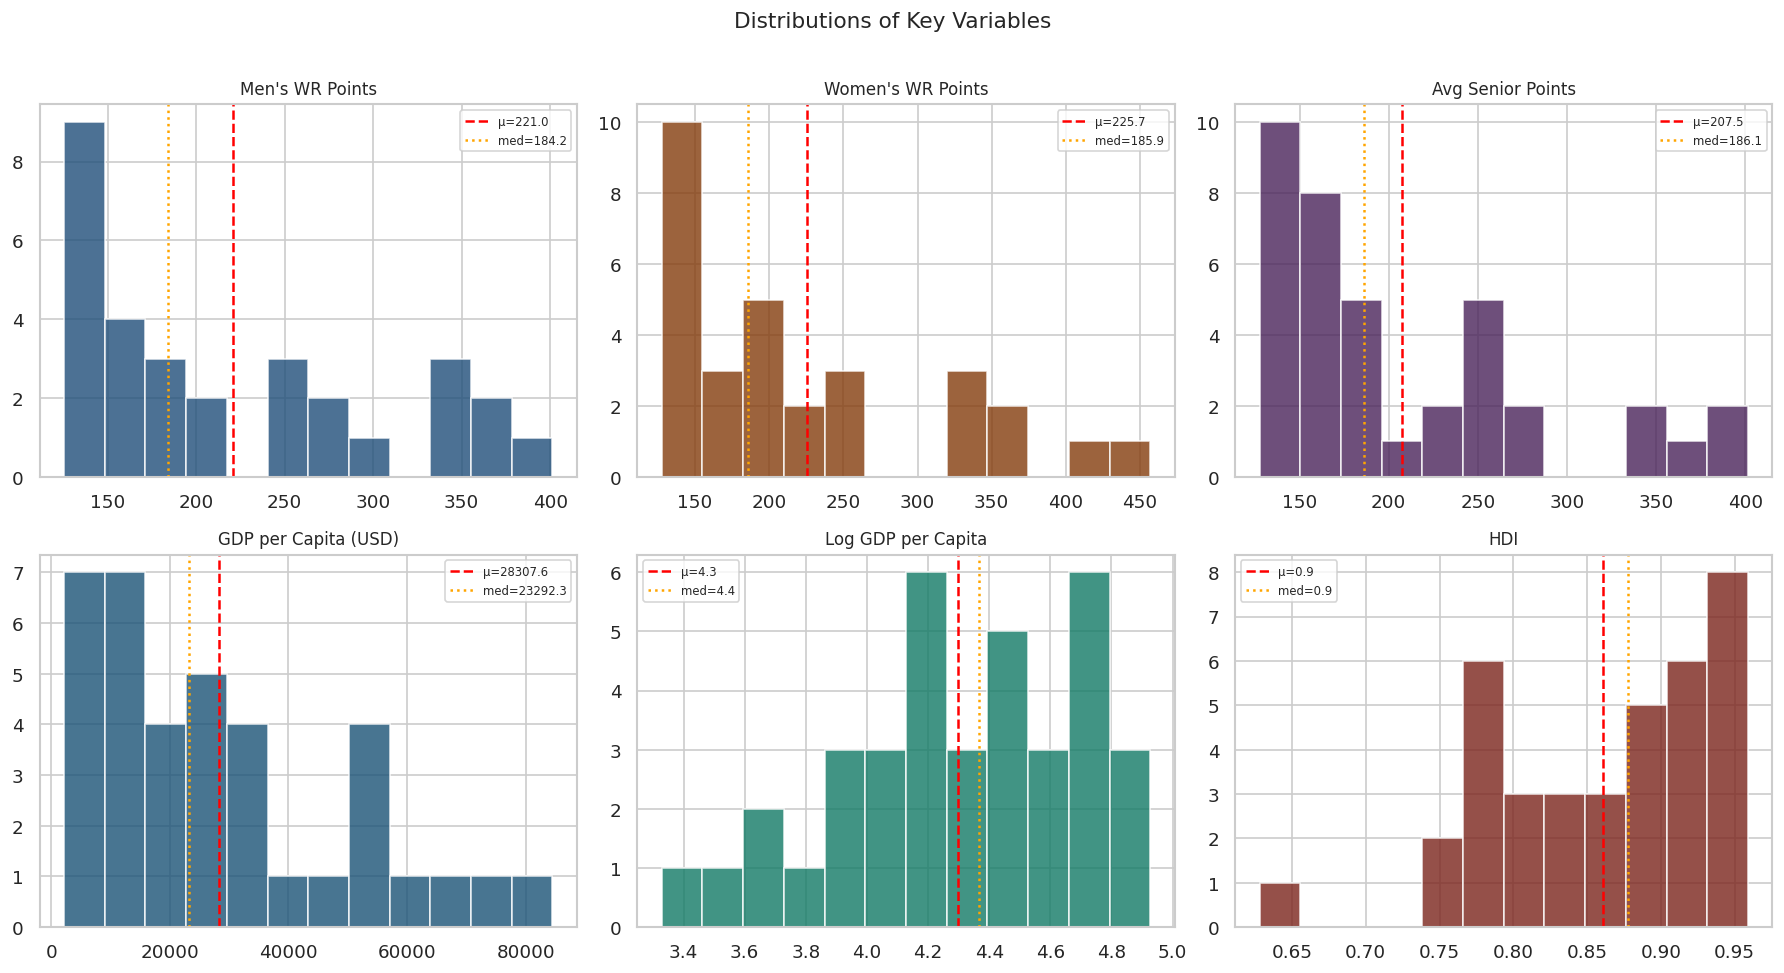

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
vars_ = [
    ("pts_men",        "Men's WR Points",       "#1F4E79"),
    ("pts_women",      "Women's WR Points",      "#843C0C"),
    ("avg_senior_pts", "Avg Senior Points",      "#4A235A"),
    ("gdp_per_capita", "GDP per Capita (USD)",   "#1A5276"),
    ("log_gdp",        "Log GDP per Capita",     "#117A65"),
    ("hdi",            "HDI",                    "#7B241C"),
]
for ax, (col, label, color) in zip(axes, vars_):
    d = df[col].dropna()
    ax.hist(d, bins=12, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(d.mean(),   color="red",    ls="--", lw=1.5, label=f"μ={d.mean():.1f}")
    ax.axvline(d.median(), color="orange", ls=":",  lw=1.5, label=f"med={d.median():.1f}")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle("Distributions of Key Variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# GDP per capita is heavily right-skewed. after log transform it looks much more symmetric —
# this is why we use log_gdp in all regression models.

## 2.2 Top 15 Countries

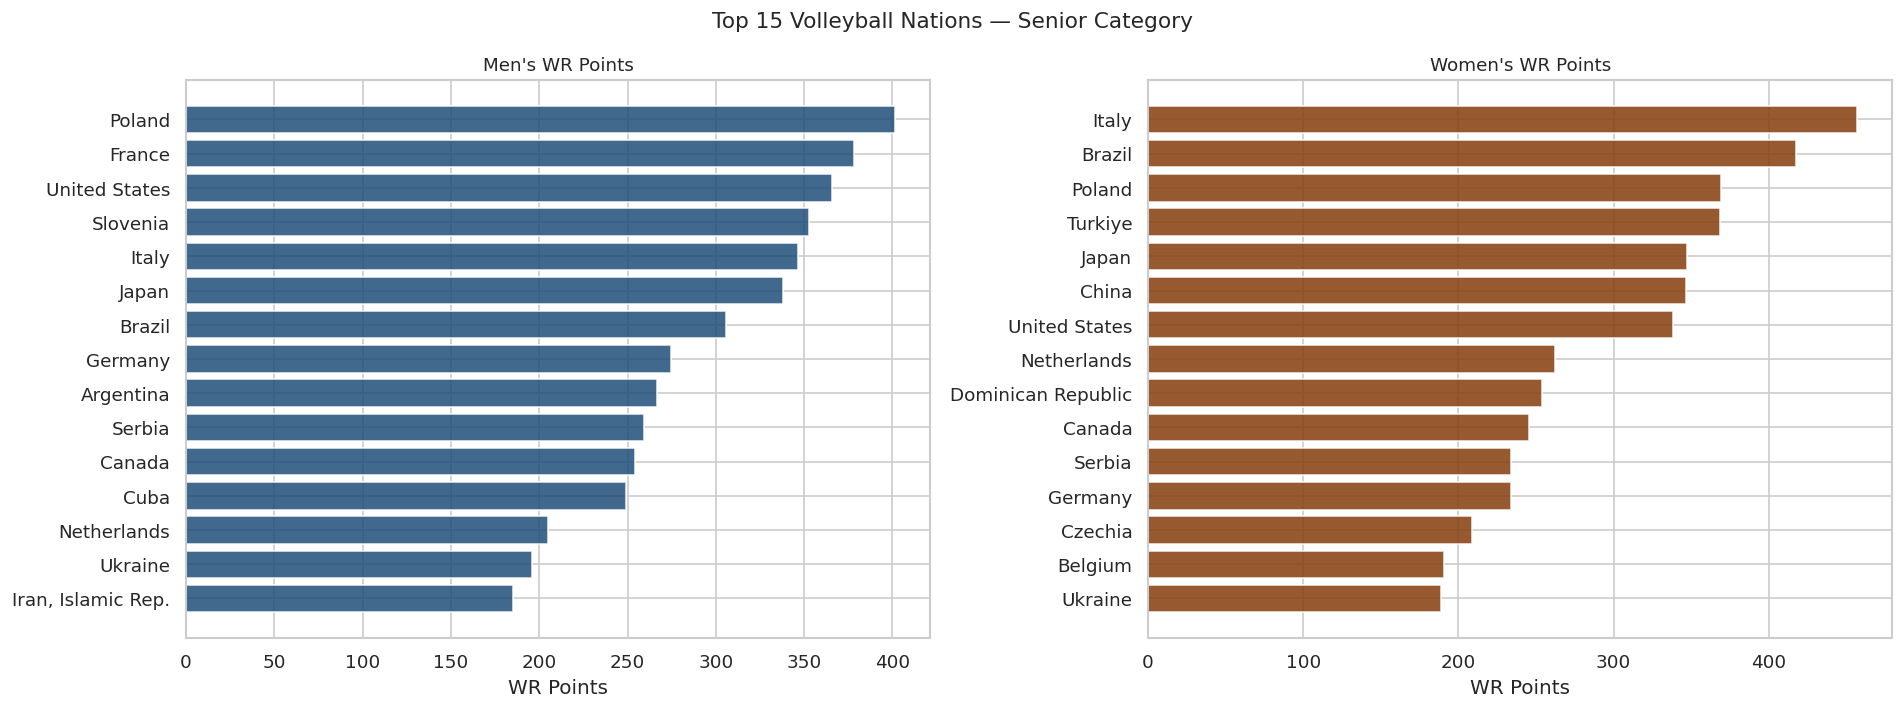

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title, color in zip(axes,
    ["pts_men","pts_women"],
    ["Men's WR Points","Women's WR Points"],
    ["#1F4E79","#843C0C"]):
    top = df[["country_std",col]].dropna().nlargest(15,col)
    ax.barh(top["country_std"], top[col], color=color, alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("WR Points")
plt.suptitle("Top 15 Volleyball Nations — Senior Category", fontsize=13)
plt.tight_layout()
plt.show()

# Europe dominates both rankings. Brazil and Japan are the only non-European nations
# consistently in the top 5-6 for both genders.

## 2.3 GDP & HDI vs Volleyball

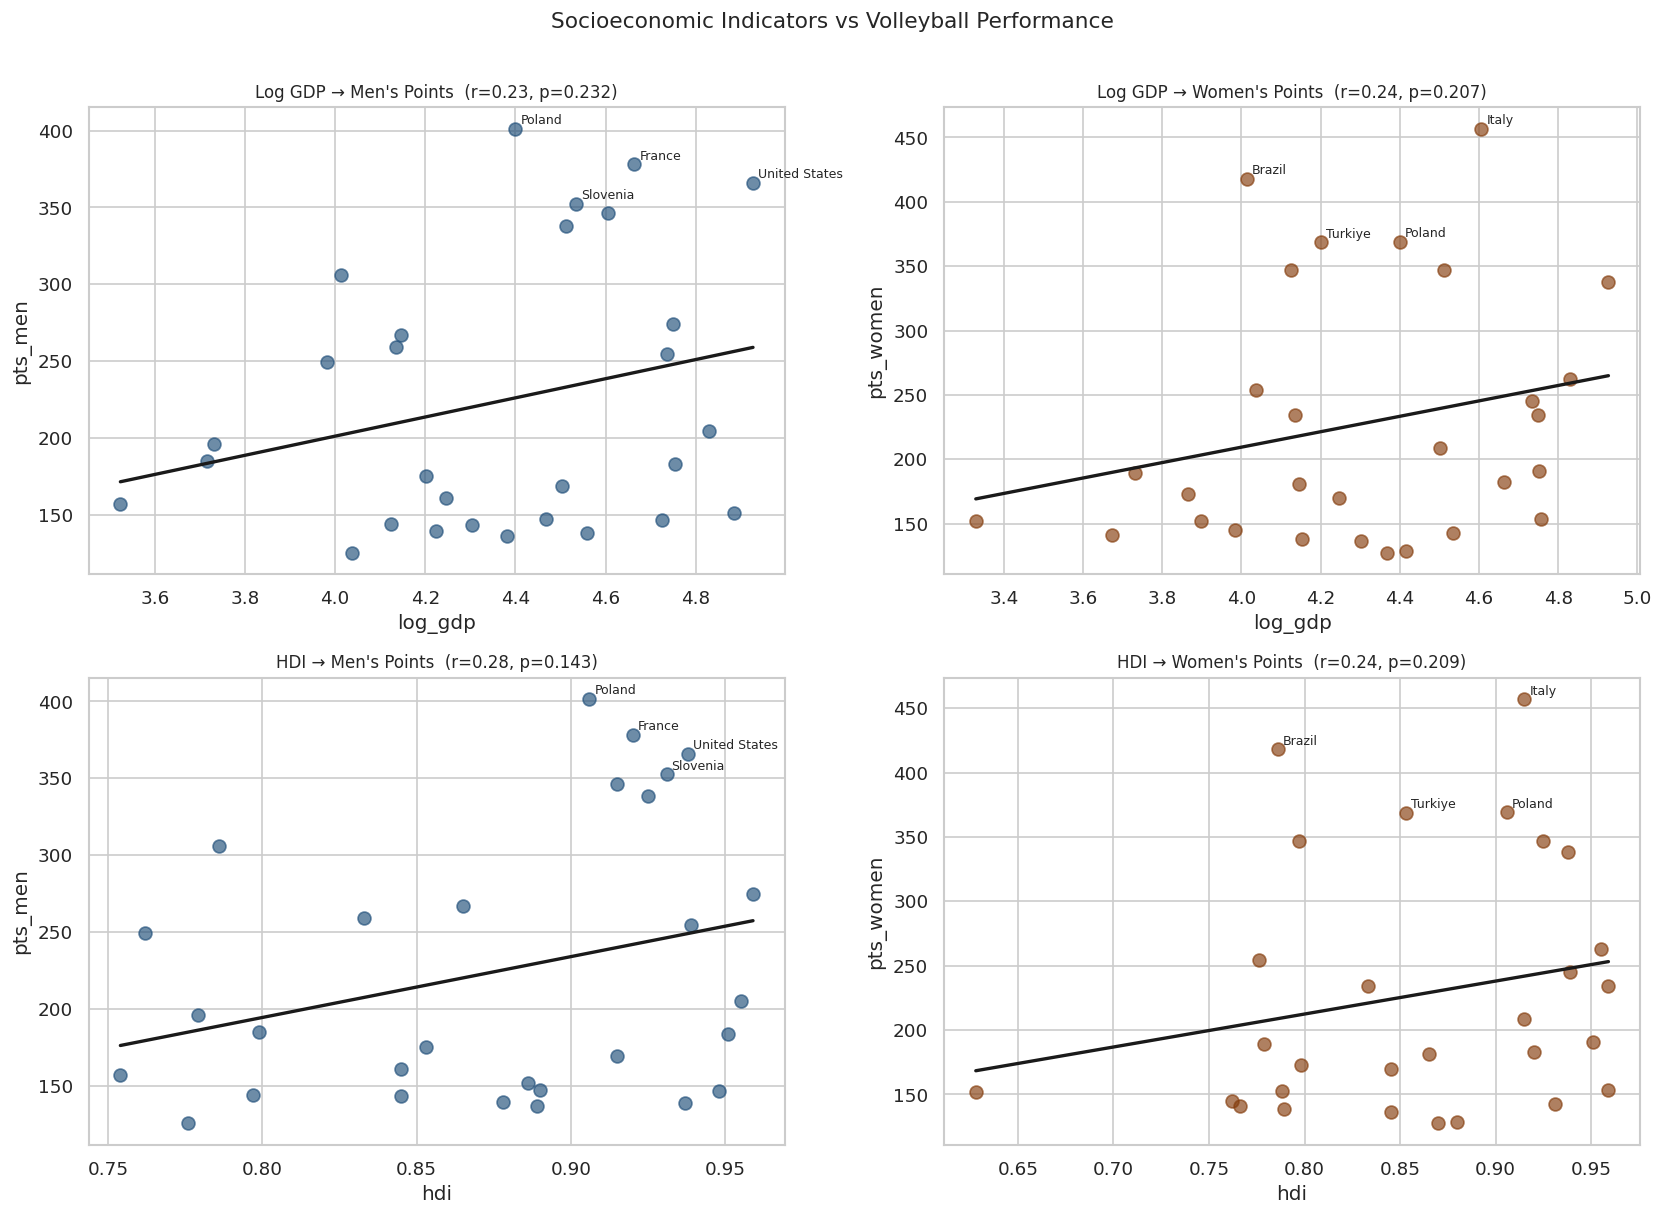

In [10]:
import warnings
warnings.filterwarnings('ignore')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
combos = [
    ("log_gdp", "pts_men",   "Log GDP → Men's Points",   "#1F4E79", axes[0,0]),
    ("log_gdp", "pts_women", "Log GDP → Women's Points", "#843C0C", axes[0,1]),
    ("hdi",     "pts_men",   "HDI → Men's Points",       "#1F4E79", axes[1,0]),
    ("hdi",     "pts_women", "HDI → Women's Points",     "#843C0C", axes[1,1]),
]
for x_col, y_col, title, color, ax in combos:
    tmp = df[["country_std",x_col,y_col]].dropna()
    ax.scatter(tmp[x_col], tmp[y_col], color=color, alpha=0.65, s=60)
    lr = LinearRegression().fit(tmp[[x_col]], tmp[y_col])
    xr = np.linspace(tmp[x_col].min(), tmp[x_col].max(), 100).reshape(-1,1)
    ax.plot(xr, lr.predict(xr), "k-", lw=2)
    for _, row in tmp.nlargest(4,y_col).iterrows():
        ax.annotate(row["country_std"], (row[x_col],row[y_col]),
                    fontsize=7.5, xytext=(3,3), textcoords="offset points")
    r, p = spearmanr(tmp[x_col], tmp[y_col])
    ax.set_title(f"{title}  (r={r:.2f}, p={p:.3f})", fontsize=10)
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
plt.suptitle("Socioeconomic Indicators vs Volleyball Performance", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# HDI correlates more strongly than GDP for both genders.
# the relationship is positive but not perfect — some countries clearly punch above their weight.

## 2.4 Gender Gap

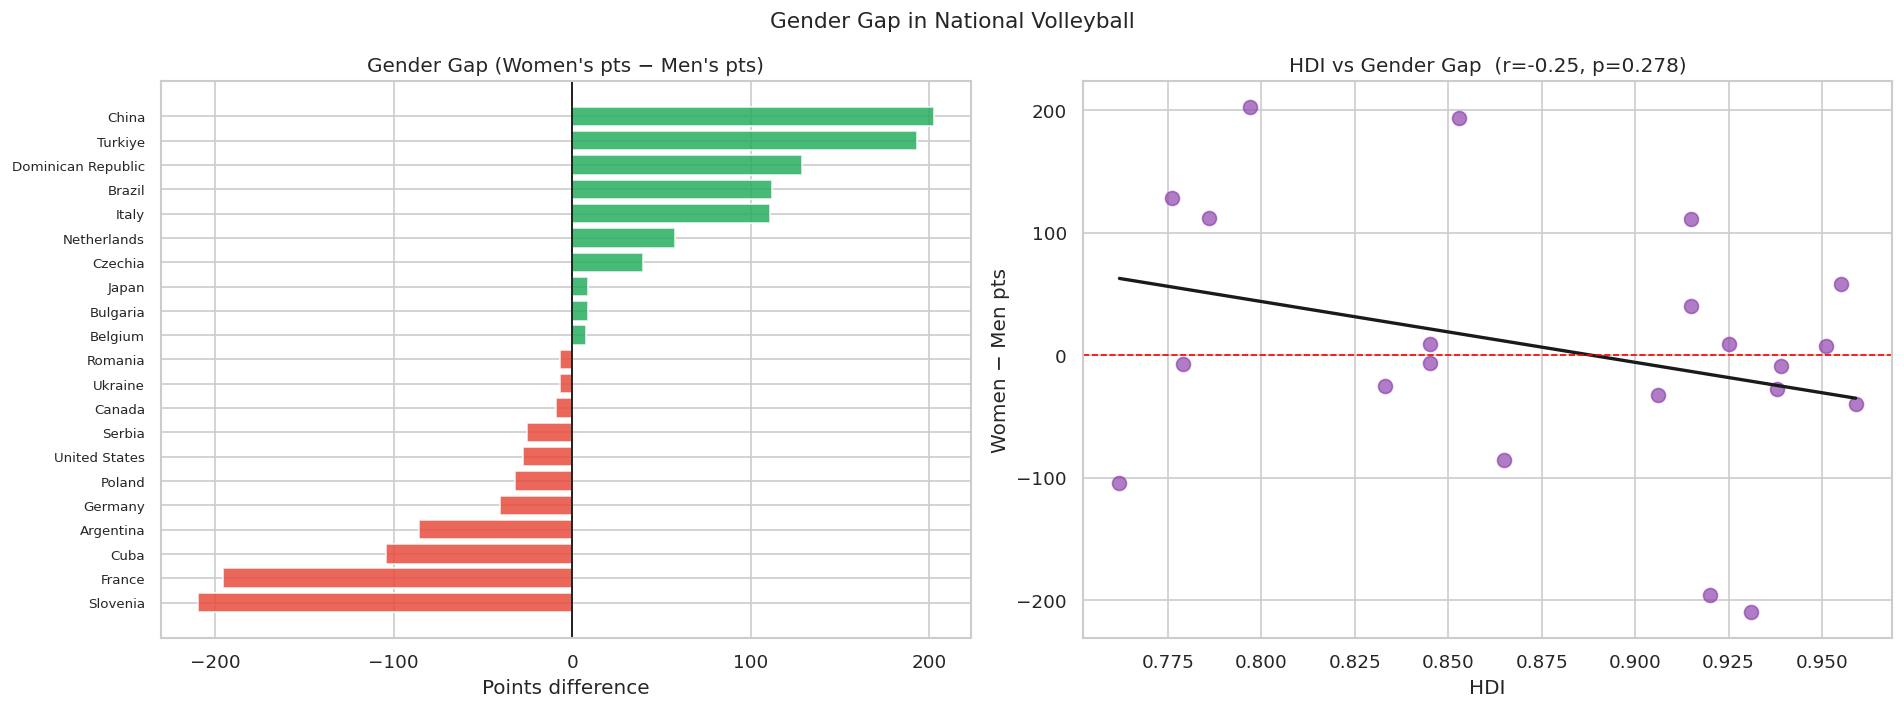

In [11]:
import warnings
warnings.filterwarnings('ignore')

tmp = df[["country_std","gender_gap","hdi"]].dropna().sort_values("gender_gap")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#27AE60" if g > 0 else "#E74C3C" for g in tmp["gender_gap"]]
axes[0].barh(tmp["country_std"], tmp["gender_gap"], color=colors, alpha=0.85)
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Gender Gap (Women's pts − Men's pts)")
axes[0].set_xlabel("Points difference")
axes[0].tick_params(axis="y", labelsize=8)

axes[1].scatter(tmp["hdi"], tmp["gender_gap"], color="#8E44AD", alpha=0.7, s=70)
lr = LinearRegression().fit(tmp[["hdi"]], tmp["gender_gap"])
xr = np.linspace(tmp["hdi"].min(), tmp["hdi"].max(), 100).reshape(-1,1)
axes[1].plot(xr, lr.predict(xr), "k-", lw=2)
axes[1].axhline(0, color="red", ls="--", lw=1)
r, p = spearmanr(tmp["hdi"], tmp["gender_gap"])
axes[1].set_title(f"HDI vs Gender Gap  (r={r:.2f}, p={p:.3f})")
axes[1].set_xlabel("HDI"); axes[1].set_ylabel("Women − Men pts")

plt.suptitle("Gender Gap in National Volleyball", fontsize=13)
plt.tight_layout()
plt.show()

# Turkey and Brazil have a strong positive gap — women's team is clearly dominant there.
# the HDI-gender gap relationship is weak, so development alone doesn't explain
# why some countries favor women's volleyball over men's.

## 2.5 Population Paradox & Confederation Patterns

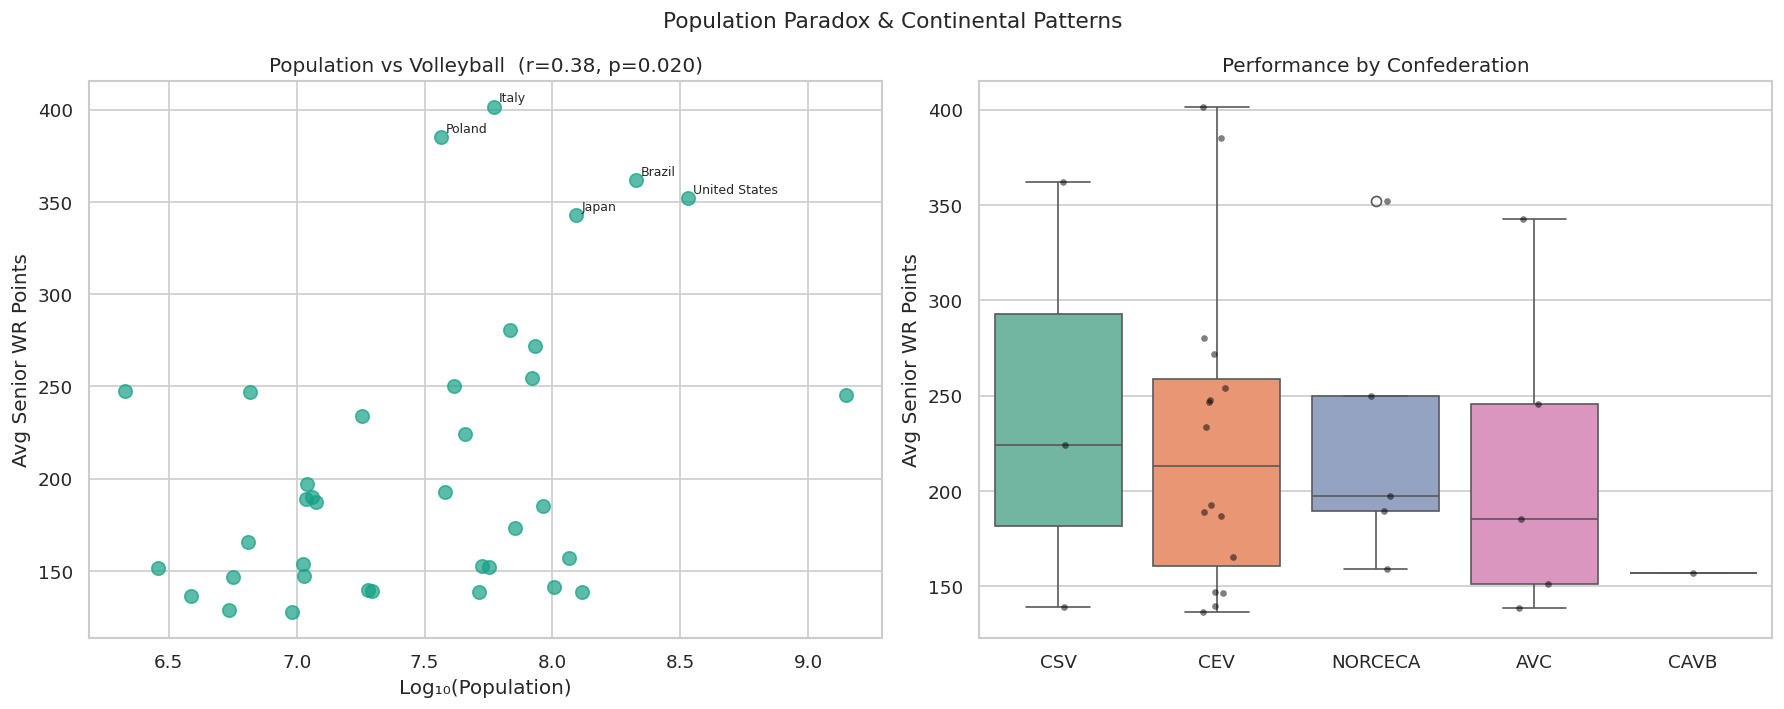

In [12]:
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tmp_pop = df[["country_std","log_population","avg_senior_pts"]].dropna()
axes[0].scatter(tmp_pop["log_population"], tmp_pop["avg_senior_pts"],
                color="#16A085", alpha=0.7, s=65)
lr = LinearRegression().fit(tmp_pop[["log_population"]], tmp_pop["avg_senior_pts"])
xr = np.linspace(tmp_pop["log_population"].min(), tmp_pop["log_population"].max(), 100).reshape(-1,1)
9
for _, row in tmp_pop.nlargest(5,"avg_senior_pts").iterrows():
    axes[0].annotate(row["country_std"], (row["log_population"],row["avg_senior_pts"]),
                     fontsize=7.5, xytext=(3,3), textcoords="offset points")
r, p = spearmanr(tmp_pop["log_population"], tmp_pop["avg_senior_pts"])
axes[0].set_title(f"Population vs Volleyball  (r={r:.2f}, p={p:.3f})")
axes[0].set_xlabel("Log₁₀(Population)"); axes[0].set_ylabel("Avg Senior WR Points")

if "confederation" in df.columns:
    tmp_c = df.dropna(subset=["avg_senior_pts","confederation"])
    order = tmp_c.groupby("confederation")["avg_senior_pts"].median().sort_values(ascending=False).index
    sns.boxplot(data=tmp_c, x="confederation", y="avg_senior_pts",
                order=order, palette="Set2", ax=axes[1])
    sns.stripplot(data=tmp_c, x="confederation", y="avg_senior_pts",
                  order=order, color="black", alpha=0.5, size=4, ax=axes[1])
    axes[1].set_title("Performance by Confederation")
    axes[1].set_xlabel(""); axes[1].set_ylabel("Avg Senior WR Points")

plt.suptitle("Population Paradox & Continental Patterns", fontsize=13)
plt.tight_layout()
plt.show()

# population has almost no correlation with volleyball success — Slovenia
# (~2M people) ranks higher than most countries 10x its size.
# CEV (Europe) median is clearly higher than other confederations.